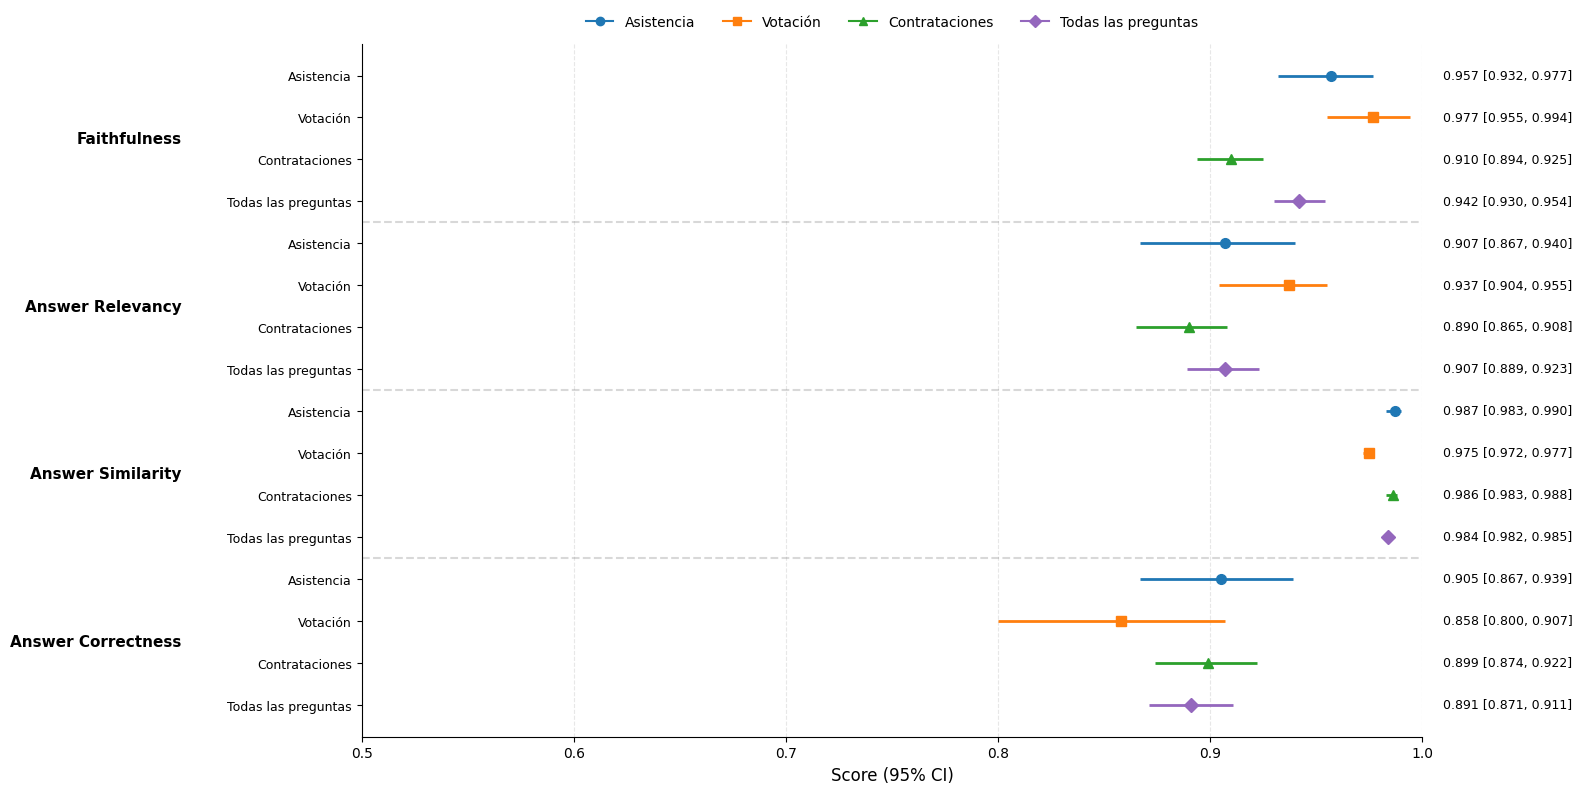

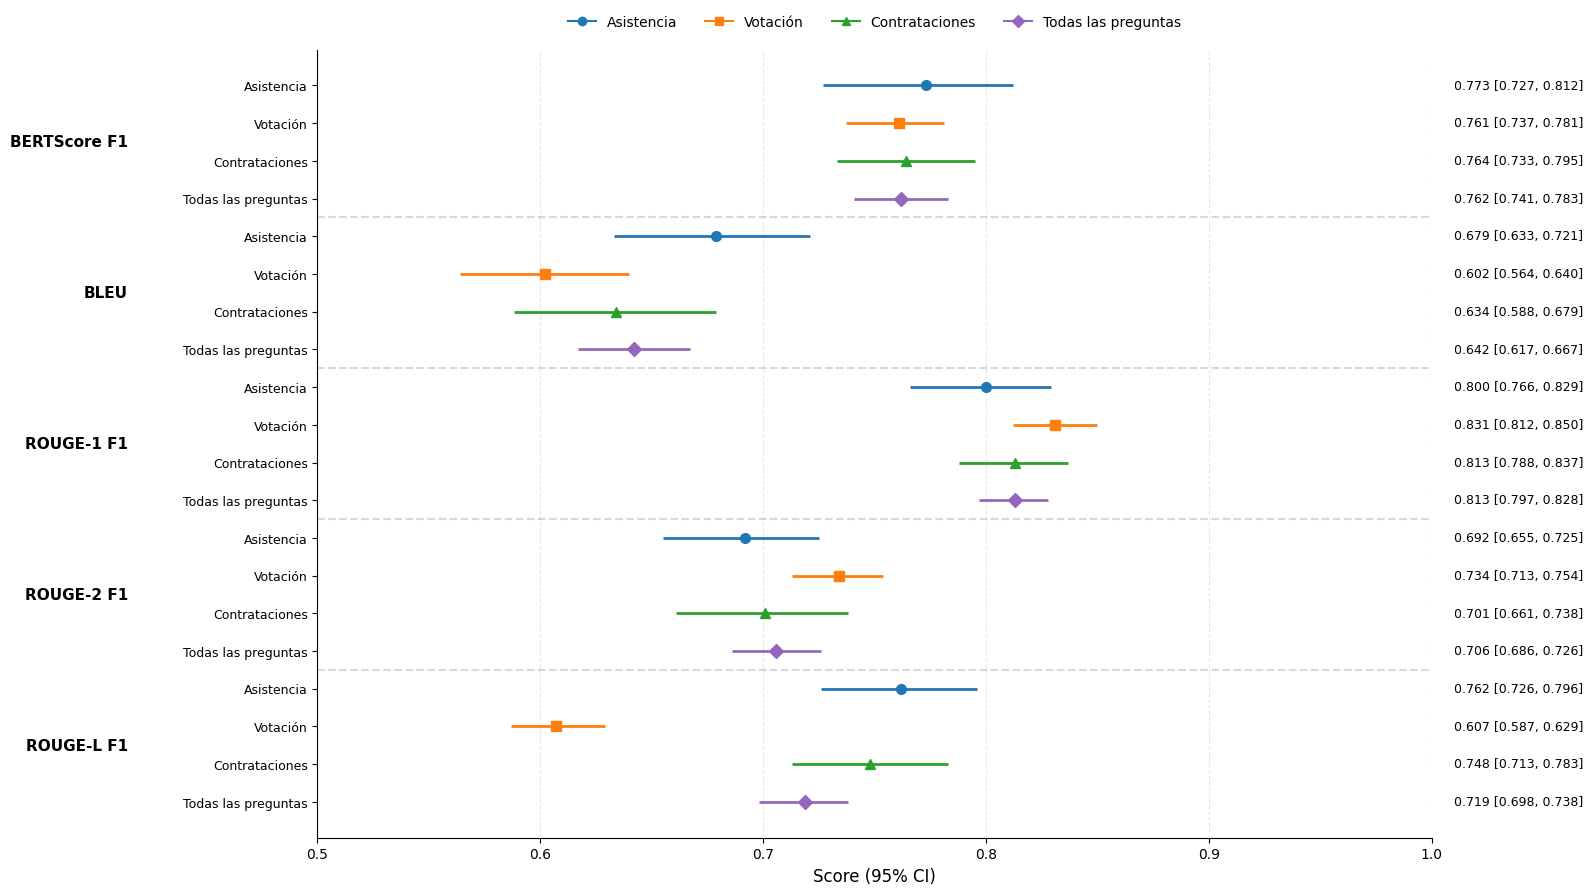

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

rows = [
    ("Asistencia", "Faithfulness", 0.957, 0.932, 0.977),
    ("Votación", "Faithfulness", 0.977, 0.955, 0.994),
    ("Contrataciones", "Faithfulness", 0.910, 0.894, 0.925),
    ("Todas las preguntas", "Faithfulness", 0.942, 0.930, 0.954),

    ("Asistencia", "Answer Relevancy", 0.907, 0.867, 0.940),
    ("Votación", "Answer Relevancy", 0.937, 0.904, 0.955),
    ("Contrataciones", "Answer Relevancy", 0.890, 0.865, 0.908),
    ("Todas las preguntas", "Answer Relevancy", 0.907, 0.889, 0.923),

    ("Asistencia", "Answer Similarity", 0.987, 0.983, 0.990),
    ("Votación", "Answer Similarity", 0.975, 0.972, 0.977),
    ("Contrataciones", "Answer Similarity", 0.986, 0.983, 0.988),
    ("Todas las preguntas", "Answer Similarity", 0.984, 0.982, 0.985),

    ("Asistencia", "Answer Correctness", 0.905, 0.867, 0.939),
    ("Votación", "Answer Correctness", 0.858, 0.800, 0.907),
    ("Contrataciones", "Answer Correctness", 0.899, 0.874, 0.922),
    ("Todas las preguntas", "Answer Correctness", 0.891, 0.871, 0.911),

    ("Asistencia", "BERTScore F1", 0.773, 0.727, 0.812),
    ("Votación", "BERTScore F1", 0.761, 0.737, 0.781),
    ("Contrataciones", "BERTScore F1", 0.764, 0.733, 0.795),
    ("Todas las preguntas", "BERTScore F1", 0.762, 0.741, 0.783),

    ("Asistencia", "BLEU", 0.679, 0.633, 0.721),
    ("Votación", "BLEU", 0.602, 0.564, 0.640),
    ("Contrataciones", "BLEU", 0.634, 0.588, 0.679),
    ("Todas las preguntas", "BLEU", 0.642, 0.617, 0.667),

    ("Asistencia", "ROUGE-1 F1", 0.800, 0.766, 0.829),
    ("Votación", "ROUGE-1 F1", 0.831, 0.812, 0.850),
    ("Contrataciones", "ROUGE-1 F1", 0.813, 0.788, 0.837),
    ("Todas las preguntas", "ROUGE-1 F1", 0.813, 0.797, 0.828),

    ("Asistencia", "ROUGE-2 F1", 0.692, 0.655, 0.725),
    ("Votación", "ROUGE-2 F1", 0.734, 0.713, 0.754),
    ("Contrataciones", "ROUGE-2 F1", 0.701, 0.661, 0.738),
    ("Todas las preguntas", "ROUGE-2 F1", 0.706, 0.686, 0.726),

    ("Asistencia", "ROUGE-L F1", 0.762, 0.726, 0.796),
    ("Votación", "ROUGE-L F1", 0.607, 0.587, 0.629),
    ("Contrataciones", "ROUGE-L F1", 0.748, 0.713, 0.783),
    ("Todas las preguntas", "ROUGE-L F1", 0.719, 0.698, 0.738),
]

domain_order = ["Asistencia", "Votación", "Contrataciones", "Todas las preguntas"]

colors = {
    "Asistencia": "#1f77b4",
    "Votación": "#ff7f0e",
    "Contrataciones": "#2ca02c",
    "Todas las preguntas": "#9467bd",
}

markers = {
    "Asistencia": "o",
    "Votación": "s",
    "Contrataciones": "^",
    "Todas las preguntas": "D",
}


def plot_metrics(selected_metrics, filename, xlim, figsize):
    grouped = defaultdict(list)

    for domain, metric, mean, low, high in rows:
        if metric in selected_metrics:
            grouped[metric].append((domain, mean, low, high))

    plot_data = []
    y_labels = []
    metric_positions = {}
    separators = []
    idx = 0

    for metric in selected_metrics:
        group_sorted = sorted(
            grouped[metric],
            key=lambda x: domain_order.index(x[0])
        )

        metric_positions[metric] = []

        for domain, mean, low, high in group_sorted:
            plot_data.append((domain, metric, mean, low, high))
            y_labels.append(domain)
            metric_positions[metric].append(idx)
            idx += 1

        separators.append(idx - 0.5)

    y = np.arange(len(plot_data))[::-1]
    fig, ax = plt.subplots(figsize=figsize)

    for i, (domain, metric, mean, low, high) in enumerate(plot_data):
        yy = y[i]

        ax.errorbar(
            mean,
            yy,
            xerr=[[mean - low], [high - mean]],
            fmt=markers[domain],
            color=colors[domain],
            markersize=7,
            linewidth=2,
        )

        ax.text(
            1.02,
            yy,
            f"{mean:.3f} [{low:.3f}, {high:.3f}]",
            transform=ax.get_yaxis_transform(),
            va="center",
            fontsize=9,
        )

    for metric, indices in metric_positions.items():
        y_pos = np.mean([y[i] for i in indices])

        ax.text(
            -0.17,
            y_pos,
            metric,
            transform=ax.get_yaxis_transform(),
            ha="right",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

    for sep in separators[:-1]:
        ax.axhline(y=sep, color="gray", linestyle="--", alpha=0.3)

    ax.set_yticks(y)
    ax.set_yticklabels(y_labels, fontsize=9)

    ax.set_xlabel("Score (95% CI)", fontsize=12)
    ax.set_xlim(*xlim)

    ax.grid(axis="x", linestyle="--", alpha=0.3)

    for domain in colors:
        ax.plot([], [], marker=markers[domain], color=colors[domain], label=domain)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.06),
        ncol=4,
        frameon=False,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.subplots_adjust(left=0.36, right=0.74)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# =========================
# GRÁFICO 1: RAGAS
# =========================
ragas_metrics = [
    "Faithfulness",
    "Answer Relevancy",
    "Answer Similarity",
    "Answer Correctness",
]

plot_metrics(
    selected_metrics=ragas_metrics,
    filename="11_llm_split_ragas.png",
    xlim=(0.50, 1.00),
    figsize=(15, 8),
)


# =========================
# GRÁFICO 2: MÉTRICAS CLÁSICAS
# =========================
classic_metrics = [
    "BERTScore F1",
    "BLEU",
    "ROUGE-1 F1",
    "ROUGE-2 F1",
    "ROUGE-L F1",
]

plot_metrics(
    selected_metrics=classic_metrics,
    filename="11_llm_split_classic.png",
    xlim=(0.50, 1.00),
    figsize=(15, 9),
)